In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('customer_churn.csv')

# Extract the 5th column and store it in ‘customer_5’
customer_5 = df.iloc[:, 4]

# Extract the 15th column and store it in ‘customer_15’
customer_15 = df.iloc[:, 14]

# Extract all the male senior citizens whose payment method is electronic check and store the result in ‘senior_male_electronic’
senior_male_electronic = df[(df['gender'] == 'Male') & (df['SeniorCitizen'] == 1) & (df['PaymentMethod'] == 'Electronic check')]

# Extract all those customers whose tenure is greater than 70 months or their monthly charges is more than $100 and store the result in ‘customer_total_tenure’
customer_total_tenure = df[(df['tenure'] > 70) | (df['MonthlyCharges'] > 100)]

# Extract all the customers whose contract is of two years, payment method is mailed check and the value of churn is ‘Yes’ and store the result in ‘two_mail_yes’
two_mail_yes = df[(df['Contract'] == 'Two year') & (df['PaymentMethod'] == 'Mailed check') & (df['Churn'] == 'Yes')]

# Extract 333 random records from the customer_churn dataframe and store the result in ‘customer_333’
customer_333 = df.sample(n=333, random_state=42)

# Get the count of different levels from the ‘Churn’ column
churn_counts = df['Churn'].value_counts()

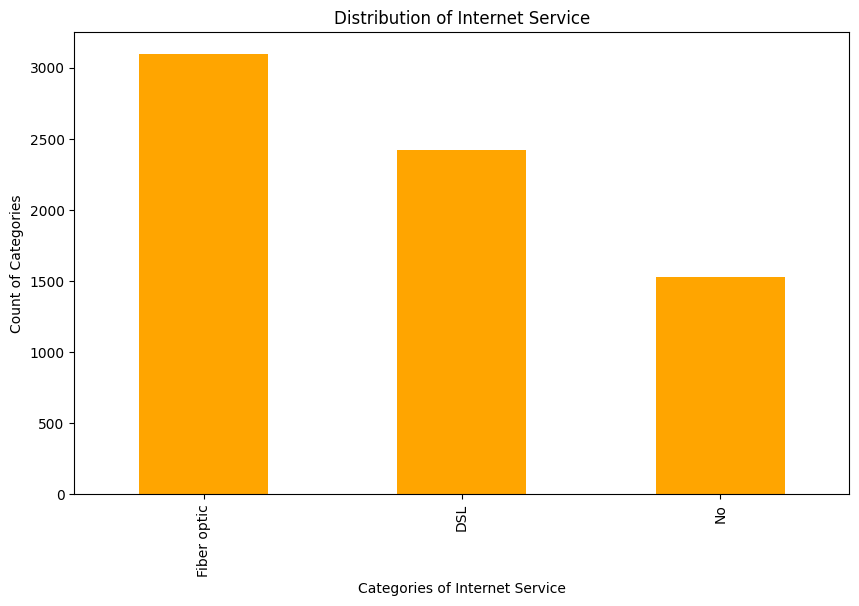

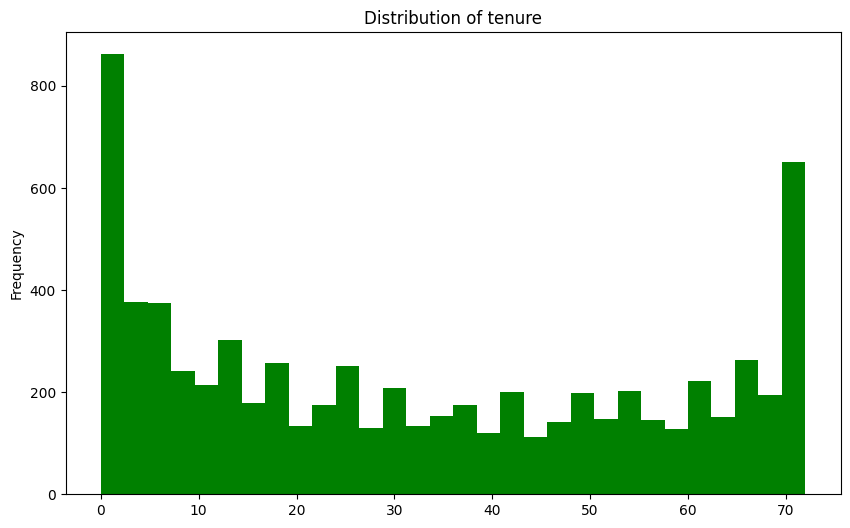

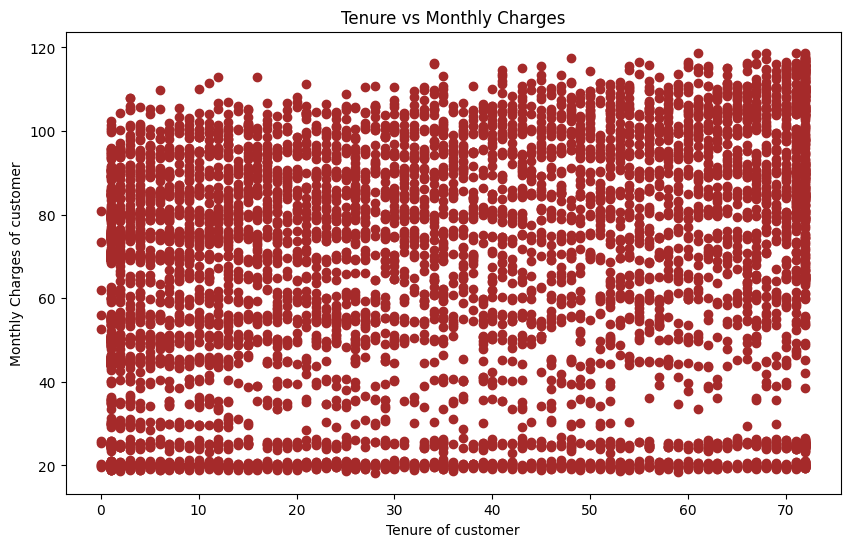

<Figure size 1000x600 with 0 Axes>

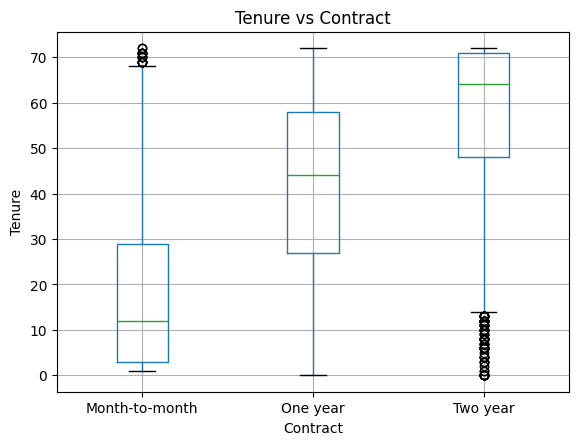

In [3]:
import matplotlib.pyplot as plt

# Build a bar-plot for the ’InternetService’ column
plt.figure(figsize=(10, 6))
df['InternetService'].value_counts().plot(kind='bar', color='orange')
plt.xlabel('Categories of Internet Service')
plt.ylabel('Count of Categories')
plt.title('Distribution of Internet Service')
plt.show()

# Build a histogram for the ‘tenure’ column
plt.figure(figsize=(10, 6))
df['tenure'].plot(kind='hist', bins=30, color='green')
plt.title('Distribution of tenure')
plt.show()

# Build a scatter-plot between ‘MonthlyCharges’ and ‘tenure’
plt.figure(figsize=(10, 6))
plt.scatter(df['tenure'], df['MonthlyCharges'], color='brown')
plt.xlabel('Tenure of customer')
plt.ylabel('Monthly Charges of customer')
plt.title('Tenure vs Monthly Charges')
plt.show()

# Build a box-plot between ‘tenure’ & ‘Contract’
plt.figure(figsize=(10, 6))
df.boxplot(column='tenure', by='Contract')
plt.title('Tenure vs Contract')
plt.suptitle('')
plt.xlabel('Contract')
plt.ylabel('Tenure')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Build a simple linear model where dependent variable is ‘MonthlyCharges’ and independent variable is ‘tenure’
X = df[['tenure']]
y = df['MonthlyCharges']

# Divide the dataset into train and test sets in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build the model on train set and predict the values on test set
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Find the root mean square error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Square Error: {rmse}')

Root Mean Square Error: 29.07936015646814


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# Build a simple logistic regression model where dependent variable is ‘Churn’ and independent variable is ‘MonthlyCharges’
X = df[['MonthlyCharges']]
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Divide the dataset in 65:35 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

# Build the model on train set and predict the values on test set
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

# Build the confusion matrix and get the accuracy score
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Accuracy: {accuracy}')

# Build a multiple logistic regression model where dependent variable is ‘Churn’ and independent variables are ‘tenure’ and ‘MonthlyCharges’
X = df[['tenure', 'MonthlyCharges']]
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Divide the dataset in 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the model on train set and predict the values on test set
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

# Build the confusion matrix and get the accuracy score
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Accuracy: {accuracy}')

Confusion Matrix:
[[1797    0]
 [ 669    0]]
Accuracy: 0.7287104622871047
Confusion Matrix:
[[944  92]
 [193 180]]
Accuracy: 0.7977288857345636


In [14]:
from sklearn.tree import DecisionTreeClassifier

# Build a decision tree model where dependent variable is ‘Churn’ and independent variable is ‘tenure’
X = df[['tenure']]
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Divide the dataset in 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the model on train set and predict the values on test set
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

# Build the confusion matrix and calculate the accuracy
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Accuracy: {accuracy}')

Confusion Matrix:
[[951  85]
 [257 116]]
Accuracy: 0.7572746628814763


In [15]:
from sklearn.ensemble import RandomForestClassifier

# Build a Random Forest model where dependent variable is ‘Churn’ and independent variables are ‘tenure’ and ‘MonthlyCharges’
X = df[['tenure', 'MonthlyCharges']]
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Divide the dataset in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build the model on train set and predict the values on test set
forest_model = RandomForestClassifier()
forest_model.fit(X_train, y_train)
y_pred = forest_model.predict(X_test)

# Build the confusion matrix and calculate the accuracy
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Accuracy: {accuracy}')

Confusion Matrix:
[[1327  212]
 [ 310  264]]
Accuracy: 0.7529578797917653
